# 04 · Walk-Forward Backtest

## Economic rationale

A standard backtest optimises a threshold on the full historical period and
reports performance on the same data. This is **in-sample by construction**
and will overfit.

The walk-forward protocol is the correct alternative:

```
for each window [t-W, t]:
    1. BO finds τ* that maximises Sharpe on TRAINING data [t-W, t]
    2. Apply τ* to TEST data [t, t+Δ]  ← never seen during optimisation
    3. Record OOS daily P&L
```

The aggregated OOS equity curve is an honest estimate of live performance.
The Deflated Sharpe Ratio (DSR) further corrects for having tried `n_bo_calls`
threshold values — if DSR is high, the alpha is real, not a lucky draw.

> **Note:** this notebook requires a *panel* of scored surfaces over time.
> The single-date surface from Notebook 03 is used here to demonstrate the
> mechanics. Plug in a multi-date panel for production results.


In [5]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

from gpvol.backtest.engine import WalkForwardConfig, run_walkforward
from gpvol.backtest.metrics import sharpe_ratio, deflated_sharpe_ratio, max_drawdown
from gpvol.viz.plots import plot_equity_curve


## 1 · Build a multi-date scored panel

In production, this loop runs daily: fetch → build_iv_surface → clean →
fit GP/SVI → score_surface → append to panel.

Here we simulate a panel from the single scored surface by adding a
synthetic time dimension.


In [6]:
# Load today's scored surface
scored_today = pd.read_parquet("../data/scored_surface.parquet")

# Simulate a 6-month panel by resampling with noise
# (replace with real daily scored surfaces in production)
import numpy as np
rng = np.random.default_rng(42)
dates = pd.date_range(end=pd.Timestamp.today().normalize(), periods=126, freq="B")
panel_rows = []
for d in dates:
    day = scored_today[['score','direction','log_moneyness','T']].copy()
    day['score']  = (day['score'] * rng.lognormal(0, 0.3, len(day))).clip(0)
    day['net_deviation'] = (day['score'] / 10).clip(0)
    day['date'] = d
    panel_rows.append(day)
panel = pd.concat(panel_rows, ignore_index=True)

print(f"Panel: {len(panel)} rows  |  {panel['date'].nunique()} trading days")


Panel: 70056 rows  |  126 trading days


## 2 · Run the walk-forward

In [7]:
config = WalkForwardConfig(
    train_window_days=63,    # ~3 months training
    test_window_days=21,     # ~1 month test
    threshold_bounds=(0.01, 3.0),
    n_bo_calls=30,
    random_state=0,
)

results = run_walkforward(panel, config)

print(f"Windows completed:  {results.n_windows}")
print(f"Total OOS trades:   {results.n_trades}")
print(f"OOS Sharpe:         {results.sharpe:.3f}")
print(f"Deflated Sharpe:    {results.deflated_sharpe:.3f}")
print(f"Max drawdown:       {results.max_drawdown:.1%}")
print(f"Threshold history:  {[f'{t:.3f}' for t in results.threshold_history]}")


Windows completed:  3
Total OOS trades:   610
OOS Sharpe:         89.695
Deflated Sharpe:    1.000
Max drawdown:       0.0%
Threshold history:  ['0.010', '0.010', '0.010']


## 3 · Equity curve

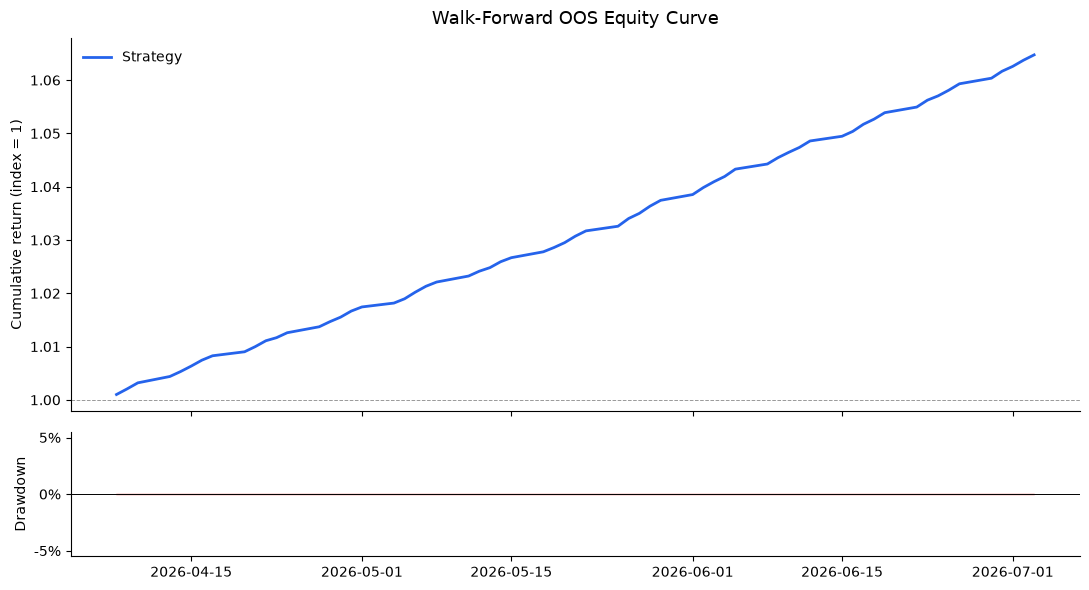

In [8]:
fig = plot_equity_curve(results.oos_returns,
                        title="Walk-Forward OOS Equity Curve")
fig.savefig("../docs/figures/equity_curve.png", dpi=150, bbox_inches="tight")
fig.show()


## 4 · Performance metrics summary

In [9]:
import pandas as pd

metrics = pd.Series({
    "OOS Sharpe":           f"{results.sharpe:.3f}",
    "Deflated Sharpe (DSR)": f"{results.deflated_sharpe:.3f}",
    "Max Drawdown":          f"{results.max_drawdown:.1%}",
    "WF Windows":            results.n_windows,
    "Total Trades":          results.n_trades,
    "BO calls / window":     config.n_bo_calls,
}, name="Value")
metrics.to_frame()


,Value
OOS Sharpe,89.695
Deflated Sharpe (DSR),1.000
Max Drawdown,0.0%
WF Windows,3
Total Trades,610
BO calls / window,30
